# Project 1. Predicting the housing price

## This code helps us prepare our data for the training. The data preprocessing helps us :
- split data into testing and training data (Usually 80% training and 20% testing dataset)
- understand data leakage and avoid it
- feature scaling

In [4]:
# import relevant packages/libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame=True)
df = housing.frame

### Split into training and testing data (80% t)

In [6]:
from sklearn.model_selection import train_test_split

X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,  # size of the testing data
    random_state=42 # randomize the dataset to avoid any bias in selecting the dataset
)

### Scaling the features: To make all the variables in the same range (0,1)
#### fit_transform on the training dataset and transform on the test dataset

In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

### Pipeline: A pipeline automates preprocessing and modeling. 
### Now, when you call pipeline.predict(X_test), the scaling is automatically applied using the parameters learned from the training data.

In [23]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LinearRegression())
])

pipeline.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()), ('model', LinearRegression())])

In [25]:
y_actual = y_test
y_pred = pipeline.predict(X_test)

model = pipeline.named_steps["model"]

print("Intercept:", model.intercept_)

coef = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

print(coef)

Intercept: 2.0719469373788777
      Feature  Coefficient
0      MedInc     0.854383
1    HouseAge     0.122546
2    AveRooms    -0.294410
3   AveBedrms     0.339259
4  Population    -0.002308
5    AveOccup    -0.040829
6    Latitude    -0.896929
7   Longitude    -0.869842


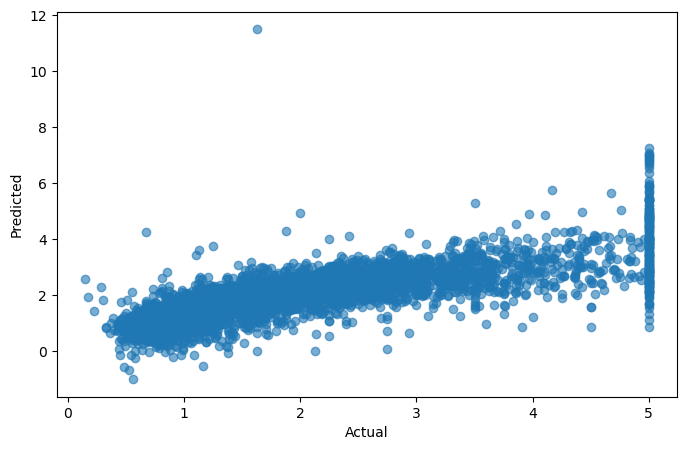

In [29]:
plt.figure(figsize=(8,5))

plt.scatter(y_actual, y_pred, alpha=0.6)
plt.xlabel("Actual")
plt.ylabel("Predicted")

plt.show()